In [4]:
import rustworkx as rx
import matplotlib.pyplot as plt
import numpy as np
from tn4qa.quantum_algorithms.hamiltonian_simulation.qdrift import QDriftSimulation
from nbed.ham_builder import HamiltonianBuilder
import pyscf
import qiskit.qasm2
import json

from ferrmion.hamiltonians import molecular_hamiltonian
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.encode import JordanWigner, ParityEncoding, BravyiKitaev, JKMN
from ferrmion.optimize.bonsai import bonsai_algorithm
from ferrmion.optimize.topphatt import topphatt

In [2]:
garnet_edges = [
    (1, 0),
    (1, 4),
    (3, 0),
    (3, 2),
    (3, 4),
    (3, 8),
    (5, 4),
    (5, 6),
    (5, 10),
    (7, 2),
    (7, 8),
    (7, 12),
    (9, 4),
    (9, 8),
    (9, 10),
    (9, 14),
    (11, 6),
    (11, 10),
    (11, 16),
    (13, 8),
    (13, 12),
    (13, 14),
    (13, 17),
    (15, 10),
    (15, 14),
    (15, 16),
    (15, 19),
    (18, 14),
    (18, 17),
    (18, 19)
]

In [3]:
def make_ham_real(hamiltonian: dict[str, complex]) -> dict[str, float]:
    real_ham = {}
    for item in hamiltonian:
        real_ham[item] = np.real(hamiltonian[item])
    return real_ham

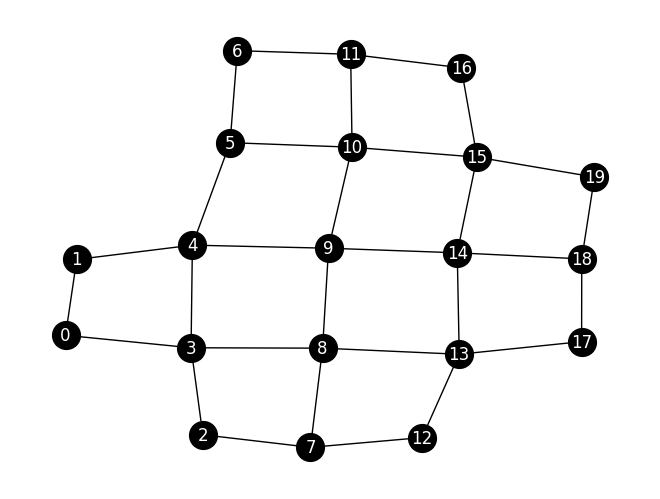

In [4]:
#rustworkx graph from edges (the actual input for bonsai)

garnet_graph_rx = rx.PyGraph()
num_qubits = max(max(pair) for pair in garnet_edges) + 1
garnet_graph_rx.add_nodes_from(range(num_qubits))
garnet_graph_rx.add_edges_from_no_data(garnet_edges)

rx.visualization.mpl_draw(
    graph = garnet_graph_rx, 
    with_labels = True,
    node_color = 'black',
    node_size = 400,
    font_color = 'white',
    pos = rx.spring_layout(garnet_graph_rx, seed=5)
)

In [5]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

print('qubits =', mol_obj.nao*2)

qubits = 14


In [6]:
rhf_obj = pyscf.scf.RHF(mol_obj).run()

converged SCF energy = -74.9659011922597


In [7]:
e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

In [8]:
def get_hams(encoding_tree, one_e_coeffs, two_e_coeffs, e_nuc):
    ham = molecular_hamiltonian(
        encoding = encoding_tree, 
        one_e_coeffs = one_e_coeffs, 
        two_e_coeffs = two_e_coeffs, 
        constant_energy = e_nuc
    )
    tophatt_tree = topphatt(
        majorana_ham = fermionic_to_sparse_majorana(((one_e_coeffs,"+-"), (two_e_coeffs, "++--"))),
        tree = encoding_tree
    )
    tophatt_ham = molecular_hamiltonian(
        encoding = tophatt_tree, 
        one_e_coeffs = one_e_coeffs, 
        two_e_coeffs = two_e_coeffs, 
        constant_energy = e_nuc
    )
    ham = make_ham_real(ham)
    tophatt_ham = make_ham_real(tophatt_ham)
    return (ham, tophatt_ham)

In [9]:
bonsai_garnet_truncated = bonsai_algorithm(
    graph = garnet_graph_rx,
    homogenous = False,
    max_nodes = 14
)

In [10]:
bonsai_hams = get_hams(
    encoding_tree = bonsai_garnet_truncated,
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [11]:
jw_hams = get_hams(
    encoding_tree = JordanWigner(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [12]:
bk_hams = get_hams(
    encoding_tree = BravyiKitaev(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [13]:
parity_hams = get_hams(
    encoding_tree = ParityEncoding(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [14]:
jkmn_hams = get_hams(
    encoding_tree = JKMN(one_e_coeffs.shape[0]),
    one_e_coeffs = one_e_coeffs,
    two_e_coeffs = two_e_coeffs,
    e_nuc = e_nuc
)

In [15]:
def run_qdrift(hams, duration):
    qdrift = QDriftSimulation(
        hamiltonian = hams[0],
        duration = duration
    )
    naive_depth = qdrift.circuit.depth()

    qdrift = QDriftSimulation(
        hamiltonian = hams[1],
        duration = duration
    )
    tophatt_depth = qdrift.circuit.depth()

    return (naive_depth, tophatt_depth)

In [16]:
results = {
    "bonsai" : {
        "hams" : bonsai_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "JW" : {
        "hams" : jw_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "BK" : {
        "hams" : bk_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "parity" : {
        "hams" : parity_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
    "JKMN" : {
        "hams" : jkmn_hams,  
        "naive" : [], 
        "topphatt" : [], 
        "naive_mean_depth" : 0,
        "naive_mean_qasm" : "",
        "topphatt_mean_depth" : 0,
        "topphatt_mean_qasm" : "",
    },
}

In [17]:
dur = 0.001
repeats = 1000

for _ in range(repeats):
    for encoding, data in results.items():
        naive_depth, tophatt_depth = run_qdrift(data["hams"], dur)
        data["naive"].append(naive_depth)
        data["topphatt"].append(tophatt_depth)

In [18]:
with open("untranspiled_results.json", 'w') as f:
    json.dump(results, f)

In [5]:
with open("untranspiled_results.json", 'r') as f:
    results = json.load(f)

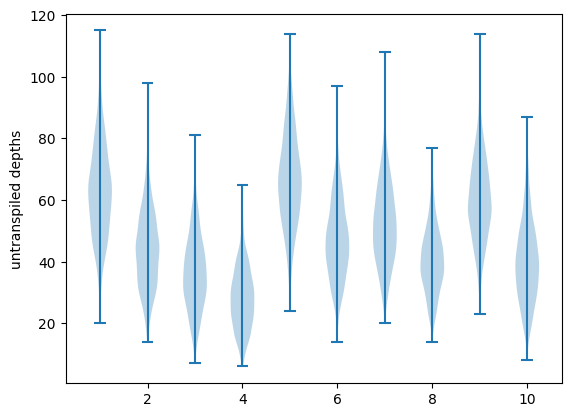

In [6]:
plt.violinplot([
    results["bonsai"]["naive"],
    results["bonsai"]["topphatt"],
    results["JW"]["naive"],
    results["JW"]["topphatt"],
    results["BK"]["naive"],
    results["BK"]["topphatt"],
    results["parity"]["naive"],
    results["parity"]["topphatt"],
    results["JKMN"]["naive"],
    results["JKMN"]["topphatt"],
])

plt.ylabel('untranspiled depths')

plt.show()

In [7]:
for encoding, data in results.items():
    print(encoding)

bonsai
JW
BK
parity
JKMN


In [12]:
order = ["JW", "parity", "BK", "JKMN", "bonsai"]
names = ["Jordan-Wigner", "Parity", "Bravyi-Kitaev", "JKMN", "Bonsai"]


JW
naive 1000
36.7 12.5
TOPP-HATT 1000
28.4 10.3
reduction
22.5 38.5

parity
naive 1000
52.2 13.3
TOPP-HATT 1000
40.4 10.7
reduction
22.6 28.4

BK
naive 1000
66.6 15.1
TOPP-HATT 1000
47.0 12.6
reduction
29.4 24.8

JKMN
naive 1000
60.2 13.5
TOPP-HATT 1000
39.8 12.9
reduction
33.9 26.1

bonsai
naive 1000
62.7 15.0
TOPP-HATT 1000
43.8 12.5
reduction
30.1 26.1


27.7, 4.5


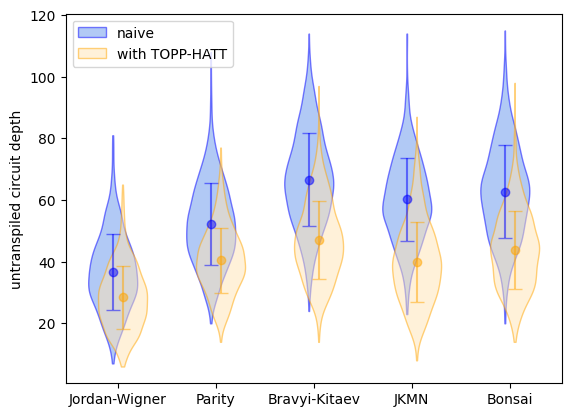

In [16]:
spacing = 0.05

naive_data   = [results[name]["naive"] for name in order]
tophatt_data = [results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with TOPP-HATT")


for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

reductions = []

for i, encoding in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(results[encoding]["naive"])
    e_naive = np.std(results[encoding]["naive"])

    y_topphatt = np.mean(results[encoding]["topphatt"])
    e_topphatt = np.std(results[encoding]["topphatt"])

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)
    
    reductions.append(100*(1 - y_topphatt/y_naive))
    
    print(encoding)
    print('naive', len(results[encoding]["naive"]))
    print(f'{y_naive:.1f}', f'{e_naive:.1f}')
    print('TOPP-HATT', len(results[encoding]["topphatt"]))
    print(f'{y_topphatt:.1f}', f'{e_topphatt:.1f}')
    print('reduction')
    print(f'{100*(1 - y_topphatt/y_naive):.1f}', f'{100*np.sqrt((y_topphatt**2 * e_naive**2)/(y_naive**4) + (e_topphatt**2)/(y_naive**2)):.1f}')
    print()

print()
print(f'{np.mean(reductions):.1f}, {np.std(reductions):.1f}')

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], names)
plt.ylabel("untranspiled circuit depth")

plt.savefig("untranspiled_qdrift.pdf")

plt.show()

In [ ]:
for encoding in results:
    print(encoding)

bonsai
JW
BK
parity
JKMN


In [24]:
for encoding in results.keys():
    data = results[encoding]
    hams = data["hams"]

    for variant, ham in zip(["naive", "topphatt"], hams):
        
        target_depth = int(np.mean(data[variant]))

        while True:
            qdrift = QDriftSimulation(hamiltonian=ham, duration=dur)

            if qdrift.circuit.depth() == target_depth:
                results[encoding][f"{variant}_mean_depth"] = target_depth
                results[encoding][f"{variant}_mean_qasm"] = qiskit.qasm2.dumps(qdrift.circuit)
                print(f"done {encoding} {variant} {target_depth}")
                break

done bonsai naive 62
done bonsai topphatt 43
done JW naive 36
done JW topphatt 28
done BK naive 66
done BK topphatt 47
done parity naive 52
done parity topphatt 40
done JKMN naive 60
done JKMN topphatt 39


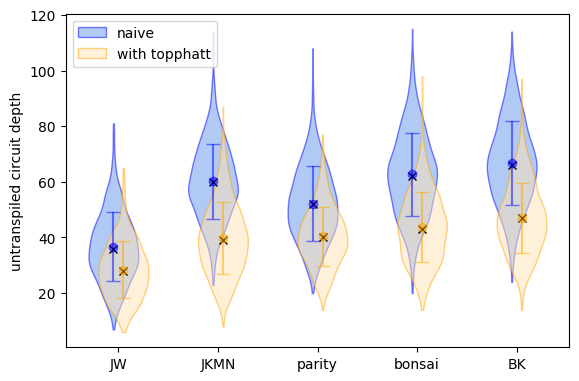

In [25]:
spacing = 0.05

naive_data   = [results[name]["naive"] for name in order]
tophatt_data = [results[name]["topphatt"]    for name in order]

positions_naive   = [i + 1 - spacing for i in range(len(order))]
positions_tophatt = [i + 1 + spacing for i in range(len(order))]

plt.figure(figsize=(468/72, (468*(2/3))/72))
plt.tight_layout()

naive_violin = plt.violinplot(
    dataset=naive_data,
    positions=positions_naive,
)
tophatt_violin = plt.violinplot(
    dataset=tophatt_data,
    positions=positions_tophatt,
)

alpha = 0.5
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

for i, body in enumerate(naive_violin['bodies']):
    body.set_facecolor(naive_fill)
    body.set_edgecolor(naive_edge)
    body.set_alpha(alpha)

naive_violin['bodies'][0].set_label("naive")

for i, body in enumerate(tophatt_violin['bodies']):
    body.set_facecolor(tophatt_fill)
    body.set_edgecolor(tophatt_edge)
    body.set_alpha(alpha)

tophatt_violin['bodies'][0].set_label("with topphatt")


for key in ["cbars", "cmaxes", "cmins"]:
    naive_violin[key].set_color("none")
    tophatt_violin[key].set_color("none")

for i, name in enumerate(order):
    x_naive = positions_naive[i]
    x_topphatt = positions_tophatt[i]

    y_naive = np.mean(results[name]["naive"])
    e_naive = np.std(results[name]["naive"])

    y_topphatt = np.mean(results[name]["topphatt"])
    e_topphatt = np.std(results[name]["topphatt"])

    depth_naive = results[name]["naive_mean_depth"]
    depth_topphatt = results[name]["topphatt_mean_depth"]

    plt.errorbar(x=x_naive, y=y_naive,
                 yerr=e_naive, fmt='o', color=naive_edge,
                 capsize=5, alpha=alpha)

    plt.errorbar(x=x_topphatt, y=y_topphatt,
                 yerr=e_topphatt, fmt='o', color=tophatt_edge,
                 capsize=5, alpha=alpha)
    
    plt.plot(x_naive, depth_naive, 'x', color='black')
    plt.plot(x_topphatt, depth_topphatt, 'x', color='black')

plt.legend(loc="upper left")
plt.xticks([i + 1 for i in range(len(order))], order)
plt.ylabel("untranspiled circuit depth")

plt.show()

In [26]:
with open("untranspiled_results.json", 'w') as f:
    json.dump(results, f, indent=4)

In [27]:
for encoding in results.keys():
    print(encoding)

bonsai
JW
BK
parity
JKMN


In [38]:
import numpy as np

# depths: numpy array of length n with the circuit depths you measured
depths = np.array(results['JW']['naive'])
n = len(depths)

# Basic stats
mean = depths.mean()
std = depths.std(ddof=1)
se = std / np.sqrt(n)
median = np.median(depths)
p25, p75 = np.percentile(depths, [25, 75])
p95, p99 = np.percentile(depths, [95, 99])
_min, _max = depths.min(), depths.max()
cv = std / mean

# 95% CI for mean using normal approximation
ci_normal = (mean - 1.96*se, mean + 1.96*se)

# Bootstrap 95% CI for mean (recommended for non-normal distributions)
n_boot = 5000
boot_means = np.empty(n_boot)
rng = np.random.default_rng(seed=12345)
for i in range(n_boot):
    sample = rng.choice(depths, size=n, replace=True)
    boot_means[i] = sample.mean()
ci_boot = (np.percentile(boot_means, 2.5), np.percentile(boot_means, 97.5))

# Trimmed mean (e.g., 10% trimmed)
from scipy.stats import trim_mean
trimmed = trim_mean(depths, proportiontocut=0.10)

print(f"n = {n}")
print(f"mean = {mean:.3f} ± SE {se:.3f}  (95% normal CI {ci_normal[0]:.3f}, {ci_normal[1]:.3f})")
# print(f"bootstrap 95% CI for mean = ({ci_boot[0]:.3f}, {ci_boot[1]:.3f})")
print(f"median = {median:.3f}, IQR = ({p25:.0f}, {p75:.0f})")
print(f"std = {std:.3f}, CV = {cv:.3f}")
print(f"min = {_min}, max = {_max}, 95th = {p95}, 99th = {p99}")
print(f"10% trimmed mean = {trimmed:.3f}")


n = 1000
mean = 36.671 ± SE 0.394  (95% normal CI 35.898, 37.444)
median = 36.000, IQR = (28, 45)
std = 12.469, CV = 0.340
min = 7, max = 81, 95th = 58.0, 99th = 69.01999999999998
10% trimmed mean = 36.184


In [39]:
import numpy as np
from scipy.stats import ks_2samp, trim_mean
from tqdm import tqdm

# ================================
# Insert your data here
# ================================
baseline = np.array(results['JW']['naive'])
optimized = np.array(results['JW']['topphatt'])
# ================================

n1, n2 = len(baseline), len(optimized)

# ---------- Basic summary -----------------
mean_base, mean_opt = baseline.mean(), optimized.mean()
median_base, median_opt = np.median(baseline), np.median(optimized)

delta_mean = mean_base - mean_opt
delta_median = median_base - median_opt
percent_reduction = 100 * delta_mean / mean_base

# ---------- Quantile differences ----------
quantiles = [5, 25, 50, 75, 95, 99]
quant_diff = {}
for q in quantiles:
    quant_diff[q] = np.percentile(baseline, q) - np.percentile(optimized, q)

# ---------- Cohen's d ----------
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled_std

cohen_d = cohens_d(baseline, optimized)

# ---------- Cliff's Delta ----------
def cliffs_delta(x, y):
    greater = 0
    smaller = 0
    for xi in x:
        greater += np.sum(xi > y)
        smaller += np.sum(xi < y)
    return (greater - smaller) / (len(x) * len(y))

cliff_delta = cliffs_delta(baseline, optimized)

# ---------- KS statistic ----------
ks_stat, ks_p = ks_2samp(baseline, optimized)

# ---------- Bootstrap CIs ----------
def bootstrap_ci(data1, data2, func, n_boot=5000):
    """
    func must be a function accepting (sample1, sample2)
    e.g. lambda a, b: a.mean() - b.mean()
    """
    rng = np.random.default_rng(1234)
    vals = np.empty(n_boot)
    for i in range(n_boot):
        bs1 = rng.choice(data1, size=len(data1), replace=True)
        bs2 = rng.choice(data2, size=len(data2), replace=True)
        vals[i] = func(bs1, bs2)
    return np.percentile(vals, [2.5, 97.5])

ci_mean = bootstrap_ci(baseline, optimized,
                       lambda a, b: a.mean() - b.mean())

ci_median = bootstrap_ci(baseline, optimized,
                         lambda a, b: np.median(a) - np.median(b))

# ======================================================
# Print everything nicely
# ======================================================
print("\n=========== SUMMARY ===========")
print(f"Baseline mean depth:   {mean_base:.3f}")
print(f"Optimized mean depth:  {mean_opt:.3f}")
print(f"Mean reduction:        {delta_mean:.3f}")
print(f"95% CI (bootstrap):    [{ci_mean[0]:.3f}, {ci_mean[1]:.3f}]")
print(f"Percent reduction:     {percent_reduction:.2f}%")
print()

print(f"Baseline median depth:  {median_base:.3f}")
print(f"Optimized median depth: {median_opt:.3f}")
print(f"Median reduction:        {delta_median:.3f}")
print(f"95% CI (bootstrap):      [{ci_median[0]:.3f}, {ci_median[1]:.3f}]")
print()

print("Quantile improvements (baseline - optimized):")
for q, d in quant_diff.items():
    print(f"  {q}th percentile: {d:.3f}")
print()

print(f"Cohen's d:     {cohen_d:.3f}")
print(f"Cliff's delta: {cliff_delta:.3f}")
print()

print(f"KS statistic:  {ks_stat:.3f}")
print(f"KS p-value:    {ks_p:.3e}")
print("================================\n")



=========== SUMMARY ===========
Baseline mean depth:   36.671
Optimized mean depth:  28.407
Mean reduction:        8.264
95% CI (bootstrap):    [7.279, 9.257]
Percent reduction:     22.54%

Baseline median depth:  36.000
Optimized median depth: 28.000
Median reduction:        8.000
95% CI (bootstrap):      [6.000, 9.000]

Quantile improvements (baseline - optimized):
  5th percentile: 5.000
  25th percentile: 7.000
  50th percentile: 8.000
  75th percentile: 10.000
  95th percentile: 12.950
  99th percentile: 12.010

Cohen's d:     0.723
Cliff's delta: 0.387

KS statistic:  0.278
KS p-value:    2.033e-34



In [40]:
import numpy as np
from scipy.stats import ks_2samp
from textwrap import dedent

# ======================================================
# INSERT YOUR DATA HERE
# ======================================================
baseline = np.array(results['JW']['naive'])
optimized = np.array(results['JW']['topphatt'])
# ======================================================

# ---------- Helper: bootstrapped CI ----------
def bootstrap_ci(data1, data2, func, n_boot=5000):
    rng = np.random.default_rng(1234)
    vals = np.empty(n_boot)
    for i in range(n_boot):
        bs1 = rng.choice(data1, size=len(data1), replace=True)
        bs2 = rng.choice(data2, size=len(data2), replace=True)
        vals[i] = func(bs1, bs2)
    return np.percentile(vals, [2.5, 97.5])

# ---------- Effect sizes ----------
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx - 1)*np.var(x, ddof=1) +
                      (ny - 1)*np.var(y, ddof=1)) / (nx + ny - 2))
    return (np.mean(x) - np.mean(y)) / pooled

def cliffs_delta(x, y):
    greater = 0
    smaller = 0
    for xi in x:
        greater += np.sum(xi > y)
        smaller += np.sum(xi < y)
    return (greater - smaller) / (len(x) * len(y))

# ======================================================
# Compute statistics
# ======================================================

mean_base, mean_opt = baseline.mean(), optimized.mean()
median_base, median_opt = np.median(baseline), np.median(optimized)

delta_mean = mean_base - mean_opt
delta_median = median_base - median_opt
percent_reduction = 100 * delta_mean / mean_base

ci_mean = bootstrap_ci(baseline, optimized, lambda a, b: a.mean() - b.mean())
ci_median = bootstrap_ci(baseline, optimized, lambda a, b: np.median(a) - np.median(b))

quantiles = [75, 95]
q_base = {q: np.percentile(baseline, q) for q in quantiles}
q_opt  = {q: np.percentile(optimized, q) for q in quantiles}
q_diff = {q: q_base[q] - q_opt[q] for q in quantiles}

# Effect sizes
d = cohens_d(baseline, optimized)
cliff = cliffs_delta(baseline, optimized)
ks_stat, ks_p = ks_2samp(baseline, optimized)

# ======================================================
# Formatted TABLE (plain text)
# ======================================================

def fmt_ci(val, ci):
    return f"{val:.1f} ({ci[0]:.1f}–{ci[1]:.1f})"

def fmt_plain(val):
    return f"{val:.1f}"

table = dedent(f"""
    =====================================================================
    Comparison of qDRIFT Circuit Depths (n = {len(baseline)} samples each)
    All uncertainties are 95% bootstrap confidence intervals.
    =====================================================================

    Metric                 | Baseline             | Optimized            | Improvement
    ---------------------------------------------------------------------------------
    Mean depth             | {fmt_plain(mean_base):>7}               | {fmt_plain(mean_opt):>7}             | {fmt_ci(delta_mean, ci_mean)}
    Median depth           | {fmt_plain(median_base):>7}               | {fmt_plain(median_opt):>7}             | {fmt_ci(delta_median, ci_median)}
    75th percentile        | {q_base[75]:>7.1f}               | {q_opt[75]:>7.1f}             | {q_diff[75]:.1f}
    95th percentile        | {q_base[95]:>7.1f}               | {q_opt[95]:>7.1f}             | {q_diff[95]:.1f}
    Std. deviation         | {np.std(baseline, ddof=1):>7.1f}               | {np.std(optimized, ddof=1):>7.1f}             |   —
    % reduction (mean)     |    —                 |    —                 | {percent_reduction:.1f}%
    Cohen's d              |    —                 |    —                 | {d:.2f}
    Cliff's delta          |    —                 |    —                 | {cliff:.2f}
    KS statistic           |    —                 |    —                 | {ks_stat:.2f}
    ---------------------------------------------------------------------------------
""")

print(table)

# ======================================================
# LATEX TABLE OUTPUT
# ======================================================

latex = dedent(f"""
    \\begin{{table}}[h]
    \\centering
    \\caption{{Comparison of qDRIFT circuit depths (100 random samples per method). 
    Values in parentheses are 95\\% bootstrap confidence intervals.}}
    \\begin{{tabular}}{{lccc}}
    \\hline
    Metric & Baseline & Optimized & Improvement \\\\
    \\hline
    Mean depth & {fmt_plain(mean_base)} & {fmt_plain(mean_opt)} & {fmt_ci(delta_mean, ci_mean)} \\\\
    Median depth & {fmt_plain(median_base)} & {fmt_plain(median_opt)} & {fmt_ci(delta_median, ci_median)} \\\\
    75th percentile & {q_base[75]:.1f} & {q_opt[75]:.1f} & {q_diff[75]:.1f} \\\\
    95th percentile & {q_base[95]:.1f} & {q_opt[95]:.1f} & {q_diff[95]:.1f} \\\\
    Std. deviation & {np.std(baseline, ddof=1):.1f} & {np.std(optimized, ddof=1):.1f} & --- \\\\
    Percent reduction & --- & --- & {percent_reduction:.1f}\\% \\\\
    Cohen's $d$ & --- & --- & {d:.2f} \\\\
    Cliff's $\\delta$ & --- & --- & {cliff:.2f} \\\\
    KS statistic & --- & --- & {ks_stat:.2f} \\\\
    \\hline
    \\end{{tabular}}
    \\end{{table}}
""")

print("\nLaTeX table:\n")
print(latex)



Comparison of qDRIFT Circuit Depths (n = 1000 samples each)
All uncertainties are 95% bootstrap confidence intervals.

Metric                 | Baseline             | Optimized            | Improvement
---------------------------------------------------------------------------------
Mean depth             |    36.7               |    28.4             | 8.3 (7.3–9.3)
Median depth           |    36.0               |    28.0             | 8.0 (6.0–9.0)
75th percentile        |    45.0               |    35.0             | 10.0
95th percentile        |    58.0               |    45.0             | 13.0
Std. deviation         |    12.5               |    10.3             |   —
% reduction (mean)     |    —                 |    —                 | 22.5%
Cohen's d              |    —                 |    —                 | 0.72
Cliff's delta          |    —                 |    —                 | 0.39
KS statistic           |    —                 |    —                 | 0.28
-------------

# water with different qDRIFT durations

In [17]:
import pyscf
from nbed.ham_builder import HamiltonianBuilder
from ferrmion import TernaryTree
import numpy as np
from ferrmion.hamiltonians import molecular_hamiltonian
from ferrmion.utils import fermionic_to_sparse_majorana
from ferrmion.optimize.topphatt import topphatt
from tn4qa.quantum_algorithms.hamiltonian_simulation.qdrift import QDriftSimulation
import matplotlib.pyplot as plt
import json

In [36]:
def pauli_weights(pauli_hamiltonian: dict[str, float]) -> list[float]:
    unscaled_terms = []
    scaled_terms = []
    for k, v in pauli_hamiltonian.items():
        assert v != 0
        pw = (len(k) - k.count("I")) 
        unscaled_terms.append(pw)
        scaled_terms.append(pw* np.abs(v))

    return (unscaled_terms, scaled_terms, len(pauli_hamiltonian))

In [37]:
def make_ham_real(hamiltonian: dict[str, complex]) -> dict[str, float]:
    real_ham = {}
    for item in hamiltonian:
        real_ham[item] = np.real(hamiltonian[item])
    return real_ham

In [38]:
def compare_qdrift_circuit(
        one_e_coeffs, 
        two_e_coeffs, 
        constant_energy,
        duration
    ):
    
    tt = TernaryTree.from_hamiltonian_coefficients((one_e_coeffs, two_e_coeffs))
    jw = tt.JW()
    jw.enumeration_scheme = jw.default_enumeration_scheme()

    JW_ham = molecular_hamiltonian(
        encoding=jw, 
        one_e_coeffs=one_e_coeffs, 
        two_e_coeffs=two_e_coeffs, 
        constant_energy=constant_energy
    )

    JW_ham = make_ham_real(JW_ham)

    majorana_ham = fermionic_to_sparse_majorana(
        [(one_e_coeffs, "+-"), (two_e_coeffs, "++--")]
    )

    TH_tree = topphatt(
        majorana_ham=majorana_ham,
        tree=jw
    )

    TH_ham = molecular_hamiltonian(
        encoding=TH_tree,
        one_e_coeffs=one_e_coeffs,
        two_e_coeffs=two_e_coeffs,
        constant_energy=constant_energy,
    )

    TH_ham = make_ham_real(TH_ham)

    QD_JW = QDriftSimulation(
        hamiltonian=JW_ham,
        duration=duration
    )

    QD_TH = QDriftSimulation(
        hamiltonian=TH_ham,
        duration=duration
    )

    return QD_JW.circuit.depth(), QD_TH.circuit.depth()

In [39]:
mol_obj = pyscf.M(
    atom = 'mols/H2O.xyz',
    basis = 'sto-3g'
)

rhf_obj = pyscf.scf.RHF(mol_obj).run()

e_nuc, one_e_coeffs, two_e_coeffs = HamiltonianBuilder(
    scf_method=rhf_obj,
    constant_e_shift=mol_obj.energy_nuc()
).build()

converged SCF energy = -74.9659011922597


In [40]:
depths = np.arange(0.001, 0.011, 0.0005)
depths

array([0.001 , 0.0015, 0.002 , 0.0025, 0.003 , 0.0035, 0.004 , 0.0045,
       0.005 , 0.0055, 0.006 , 0.0065, 0.007 , 0.0075, 0.008 , 0.0085,
       0.009 , 0.0095, 0.01  , 0.0105])

In [41]:
results = {str(i) : {"JW" : [], "TH" : []} for i, _ in enumerate(depths)}

In [42]:
results

{'0': {'JW': [], 'TH': []},
 '1': {'JW': [], 'TH': []},
 '2': {'JW': [], 'TH': []},
 '3': {'JW': [], 'TH': []},
 '4': {'JW': [], 'TH': []},
 '5': {'JW': [], 'TH': []},
 '6': {'JW': [], 'TH': []},
 '7': {'JW': [], 'TH': []},
 '8': {'JW': [], 'TH': []},
 '9': {'JW': [], 'TH': []},
 '10': {'JW': [], 'TH': []},
 '11': {'JW': [], 'TH': []},
 '12': {'JW': [], 'TH': []},
 '13': {'JW': [], 'TH': []},
 '14': {'JW': [], 'TH': []},
 '15': {'JW': [], 'TH': []},
 '16': {'JW': [], 'TH': []},
 '17': {'JW': [], 'TH': []},
 '18': {'JW': [], 'TH': []},
 '19': {'JW': [], 'TH': []}}

In [43]:
repeats = 100

for i in range(repeats):
    for j, depth in enumerate(depths):
        JW_d, TH_d = compare_qdrift_circuit(
            one_e_coeffs, 
            two_e_coeffs, 
            e_nuc,
            duration=depth
        )
            
        results[str(j)]["JW"].append(JW_d)
        results[str(j)]["TH"].append(TH_d)

    print('done repeat', i + 1, 'of', repeats, end='\r')

In [44]:
results["depths"] = depths.tolist()

In [45]:
with open("qdrift_depths_scan.json", 'w') as f:
    json.dump(results, f, indent=4)

In [18]:
with open("qdrift_depths_scan.json", 'r') as f:
    results = json.load(f)

In [19]:
depths = results["depths"]

In [20]:
JW_mean_depths = []
JW_std_depths = []
TH_mean_depths = []
TH_std_depths = []

for i, _ in enumerate(depths):
    JW_mean_depths.append(np.mean(results[str(i)]["JW"]))
    JW_std_depths.append(np.std(results[str(i)]["JW"]))
    TH_mean_depths.append(np.mean(results[str(i)]["TH"]))
    TH_std_depths.append(np.std(results[str(i)]["TH"]))

In [38]:
reductions = []

for i, depth in enumerate(JW_mean_depths):
    reductions.append(100*(1 - TH_mean_depths[i]/depth))
    print(f'{depths[i]:.4f}', '&', f'{depth:.1f}', '&', f'{TH_mean_depths[i]:.1f}', '&',  f'{100*(1 - TH_mean_depths[i]/depth):.1f}', ''.join(['\ ' '\ ']))

print()
print(f'{np.mean(reductions):.1f}, {np.std(reductions):.1f}')

0.0010 & 35.8 & 26.8 & 25.2 \ \ 
0.0015 & 72.3 & 59.7 & 17.4 \ \ 
0.0020 & 127.9 & 98.0 & 23.4 \ \ 
0.0025 & 203.2 & 155.4 & 23.5 \ \ 
0.0030 & 289.7 & 224.0 & 22.7 \ \ 
0.0035 & 384.1 & 297.6 & 22.5 \ \ 
0.0040 & 514.1 & 383.8 & 25.4 \ \ 
0.0045 & 658.9 & 492.0 & 25.3 \ \ 
0.0050 & 799.3 & 605.5 & 24.3 \ \ 
0.0055 & 959.4 & 727.2 & 24.2 \ \ 
0.0060 & 1146.1 & 864.8 & 24.5 \ \ 
0.0065 & 1326.3 & 1018.7 & 23.2 \ \ 
0.0070 & 1531.1 & 1176.8 & 23.1 \ \ 
0.0075 & 1771.2 & 1353.9 & 23.6 \ \ 
0.0080 & 2007.7 & 1538.8 & 23.4 \ \ 
0.0085 & 2273.7 & 1730.7 & 23.9 \ \ 
0.0090 & 2557.8 & 1934.7 & 24.4 \ \ 
0.0095 & 2846.1 & 2189.2 & 23.1 \ \ 
0.0100 & 3134.7 & 2385.6 & 23.9 \ \ 
0.0105 & 3467.6 & 2654.8 & 23.4 \ \ 

23.5, 1.6


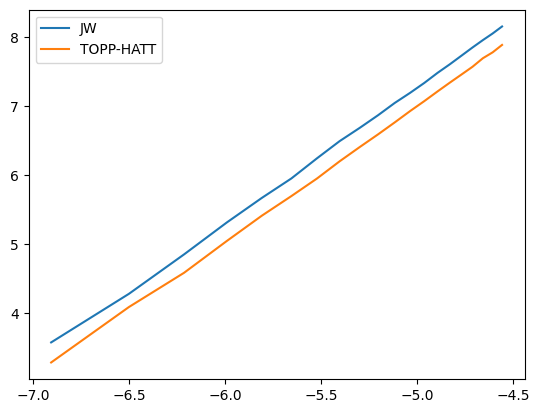

In [21]:
plt.plot(np.log(depths), np.log(JW_mean_depths), label="JW")
plt.plot(np.log(depths), np.log(TH_mean_depths), label="TOPP-HATT")

plt.legend()
plt.show()

In [5]:
JW_mean_depths = np.array(JW_mean_depths)
JW_std_depths = np.array(JW_std_depths)
TH_mean_depths = np.array(TH_mean_depths)
TH_std_depths = np.array(TH_std_depths)

In [6]:
factors = []

for i, _ in enumerate(depths):
    JW = np.array(results[str(i)]["JW"])
    TH = np.array(results[str(i)]["TH"])

    print(JW)
    print(TH)
    print()

    factor = np.exp(
        np.sum(
            np.log(JW) - np.log(TH)
        ) / len(JW)
    )

    factors.append(factor)

[32 40 30 40 29 42 29 56 59 24 31 44 55 51 57 39 19 37 29 44 52 20 24 25
 17 36 29 45 43 24 49 17 30 27 26 43 22 26 31 40 54 47 36 39 53 35 28 35
 46 45 44 41 34 45 58 36 30 41 26 50 50 48 49 37 57 37 52 29 19 36 19 24
 46 46 11 35 15 15 61 33 45 34 48 31 22 29 49 14 16 40 32 28 28 20 24 21
 18 35 38 50]
[28 32 15 38 34 15 27 17 20 51 27 54 26 12 21 19 39 36 41 35 52 46 13 36
 22 38 11 31 38 19 22 41 29 19 13 34 13 25 36 19 16 25 25 13 22 18 18 25
 28 27 21 47  9 16 14 36 17 20 30 27 39 23 22 11 19 36 27 22 34 19 10 30
 30 47 27 30 28 28 16 43 12 22 27 30 39 16 31 28 12 21 22 24 29 24 35 44
 34 33 31 22]

[ 69  85  70  74  48  61  95  42  72  98  71  83  72  86  73  51  74  67
  81  71 108  97  93  63  53  78  60  85  65  75  72  88  74  55  79  84
  70  84  56  70  69  89  64  62  63  71  49  68  65  83  84  67  84  76
  57  73  88  63  67  92  53  88  78  57  75  59  89  69  54  96  76  44
  61  76  86 103  81  74 116  49  64  50  81  55  95  79  89  80  70  58
  53  87  65  36  51  

In [7]:
JW = np.array(results[str(0)]["JW"])
TH = np.array(results[str(0)]["TH"])

In [8]:
np.log(JW) - np.log(TH)

array([ 0.13353139,  0.22314355,  0.69314718,  0.05129329, -0.15906469,
        1.02961942,  0.07145896,  1.19213835,  1.08180517, -0.7537718 ,
        0.13815034, -0.20479441,  0.74923665,  1.44691898,  0.99852883,
        0.71912267, -0.71912267,  0.02739897, -0.34627624,  0.22884157,
        0.        , -0.83290912,  0.61310447, -0.36464311, -0.25782911,
       -0.05406722,  0.96940056,  0.37267529,  0.12361396,  0.23361485,
        0.80077784, -0.88035872,  0.03390155,  0.35139789,  0.69314718,
        0.23483959,  0.5260931 ,  0.03922071, -0.14953173,  0.74444047,
        1.21639532,  0.63127178,  0.36464311,  1.09861229,  0.87924946,
        0.6649763 ,  0.44183275,  0.33647224,  0.49643689,  0.51082562,
        0.7396672 , -0.13657554,  1.32913595,  1.03407377,  1.42138568,
        0.        ,  0.56798404,  0.71783979, -0.14310084,  0.61618614,
        0.24846136,  0.73570679,  0.80077784,  1.21302264,  1.09861229,
        0.02739897,  0.65540685,  0.27625338, -0.58192155,  0.63

In [7]:
print(len(factors))

20


In [8]:
print(len(depths))

20


In [7]:
print(np.mean(factors), np.std(factors))

1.3104826585224365 0.02464700121512443


In [9]:
mean_factor = np.exp(np.sum(np.log(JW_mean_depths) - np.log(TH_mean_depths)) / len(JW_mean_depths))
mean_factor

np.float64(1.3077521179421974)

In [10]:
lower_factor = np.exp(np.sum(np.log(JW_mean_depths - JW_std_depths) - np.log(TH_mean_depths + TH_std_depths)) / len(JW_mean_depths))
lower_factor

np.float64(1.0663874144870713)

In [11]:
upper_factor = np.exp(np.sum(np.log(JW_mean_depths + JW_std_depths) - np.log(TH_mean_depths - TH_std_depths)) / len(JW_mean_depths))
upper_factor

np.float64(1.6107650539232878)

In [12]:
print(mean_factor, mean_factor - lower_factor, upper_factor - mean_factor)

1.3077521179421974 0.24136470345512606 0.30301293598109047


In [42]:
from numpy.polynomial import Polynomial

In [43]:
JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=2)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=2)

In [44]:
print(JW_fit)
print()
print(TH_fit)

1046.37643561 + 1714.3705·(-1.21052632 + 210.52631579x) +
702.91060335·(-1.21052632 + 210.52631579x)²

796.15823485 + 1309.35257143·(-1.21052632 + 210.52631579x) +
542.13179113·(-1.21052632 + 210.52631579x)²


In [45]:
JW_fit = Polynomial.fit(np.log(depths), np.log(JW_mean_depths), deg=1)
TH_fit = Polynomial.fit(np.log(depths), np.log(TH_mean_depths), deg=1)

In [46]:
print(JW_fit)
print()
print(TH_fit)

5.82824735 + 2.3128062·(4.87550223 + 0.85056607x)

5.5631601 + 2.30333873·(4.87550223 + 0.85056607x)


In [47]:
702.91060335 / 542.13179113

1.2965677623975498

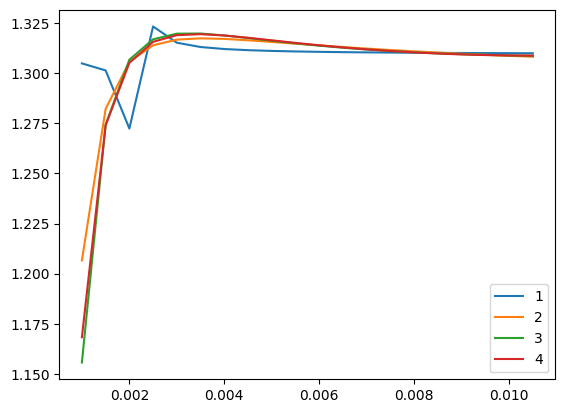

In [48]:
JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=1)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=1)
plt.plot(depths, JW_fit(depths)/TH_fit(depths), label='1')

JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=2)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=2)
plt.plot(depths, JW_fit(depths)/TH_fit(depths), label='2')

JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=3)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=3)
plt.plot(depths, JW_fit(depths)/TH_fit(depths), label='3')

JW_fit = Polynomial.fit(depths, JW_mean_depths, deg=4)
TH_fit = Polynomial.fit(depths, TH_mean_depths, deg=4)
plt.plot(depths, JW_fit(depths)/TH_fit(depths), label='4')

plt.legend()

plt.show()

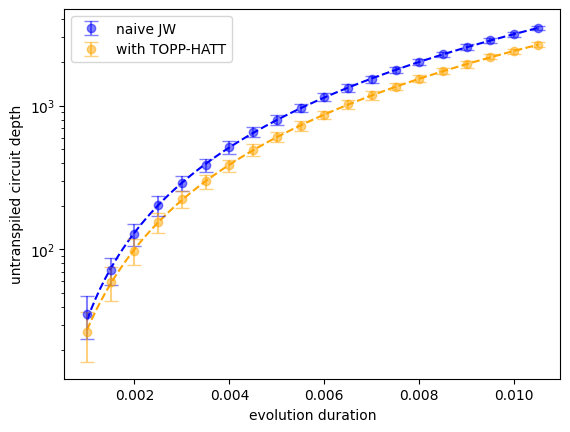

In [52]:
naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

plt.tight_layout()

# plt.plot(depths, JW_mean_depths, 'o', label='naive JW', color=naive_edge)
# plt.plot(depths, TH_mean_depths, 'o', label='with TOPP-HATT', color=tophatt_edge)

depths_fine = np.linspace(min(depths), max(depths), 100)

plt.plot(depths_fine, JW_fit(depths_fine), '--', color=naive_edge)
plt.plot(depths_fine, TH_fit(depths_fine), '--', color=tophatt_edge)

plt.errorbar(
    depths,
    JW_mean_depths,
    yerr=JW_std_depths,
    fmt='o',
    color=naive_edge,
    capsize=5,
    alpha=0.5,
    label='naive JW'
)

plt.errorbar(
    depths,
    TH_mean_depths,
    yerr=TH_std_depths,
    fmt='o',
    color=tophatt_edge,
    capsize=5,
    alpha=0.5,
    label='with TOPP-HATT' 
)

# plt.fill_between(
#     depths,
#     np.array(JW_mean_depths) - np.array(JW_std_depths),
#     np.array(JW_mean_depths) + np.array(JW_std_depths),
#     alpha=0.2,
#     color=naive_edge
# )

# plt.fill_between(
#     depths,
#     np.array(TH_mean_depths) - np.array(TH_std_depths),
#     np.array(TH_mean_depths) + np.array(TH_std_depths),
#     alpha=0.2,
#     color=tophatt_edge
# )

plt.xlabel('evolution duration')
plt.ylabel('untranspiled circuit depth')

plt.yscale('log')

plt.legend()

plt.savefig("qdrift_depths_scan.pdf")

plt.show()

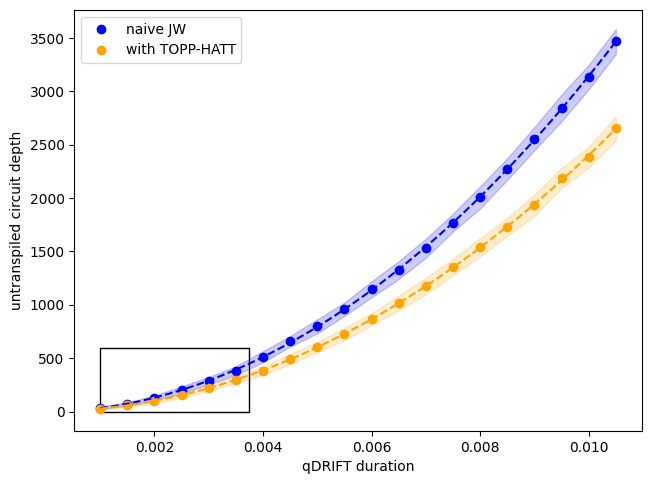

In [16]:
from matplotlib.patches import Rectangle

naive_edge = 'blue'
naive_fill = 'cornflowerblue'
tophatt_edge = 'orange'
tophatt_fill = 'moccasin'

fig, ax = plt.subplots()

plt.tight_layout()

plt.plot(depths, JW_mean_depths, 'o', label='naive JW', color=naive_edge)
plt.plot(depths, TH_mean_depths, 'o', label='with TOPP-HATT', color=tophatt_edge)

depths_fine = np.linspace(min(depths), max(depths), 100)

plt.plot(depths_fine, JW_fit(depths_fine), '--', color=naive_edge)
plt.plot(depths_fine, TH_fit(depths_fine), '--', color=tophatt_edge)

plt.fill_between(
    depths,
    np.array(JW_mean_depths) - np.array(JW_std_depths),
    np.array(JW_mean_depths) + np.array(JW_std_depths),
    alpha=0.2,
    color=naive_edge
)

plt.fill_between(
    depths,
    np.array(TH_mean_depths) - np.array(TH_std_depths),
    np.array(TH_mean_depths) + np.array(TH_std_depths),
    alpha=0.2,
    color=tophatt_edge
)

plt.xlabel('qDRIFT duration')
plt.ylabel('untranspiled circuit depth')

# ax.add_patch(Rectangle((0.001,0), 0.00275, 600))

ax.add_patch(Rectangle((0.001,0), 0.00275, 600,
             edgecolor = 'black',
             fill=False,
             lw=1))

# plt.yscale('log')

plt.legend()

plt.show()

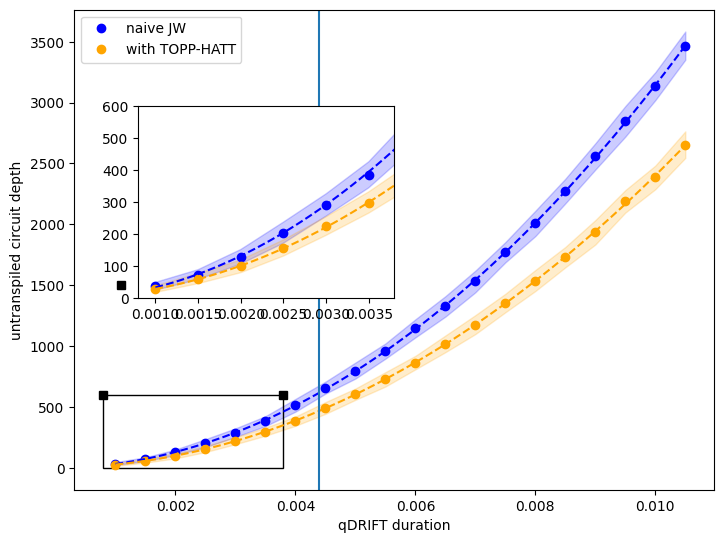

In [17]:
fig = plt.figure()

ax1 = fig.add_axes([0, 0, 1, 1])

ax1.plot(depths, JW_mean_depths, 'o', label='naive JW', color=naive_edge)
ax1.plot(depths, TH_mean_depths, 'o', label='with TOPP-HATT', color=tophatt_edge)

depths_fine = np.linspace(min(depths), max(depths), 100)

ax1.plot(depths_fine, JW_fit(depths_fine), '--', color=naive_edge)
ax1.plot(depths_fine, TH_fit(depths_fine), '--', color=tophatt_edge)

ax1.fill_between(
    depths,
    np.array(JW_mean_depths) - np.array(JW_std_depths),
    np.array(JW_mean_depths) + np.array(JW_std_depths),
    alpha=0.2,
    color=naive_edge
)

ax1.fill_between(
    depths,
    np.array(TH_mean_depths) - np.array(TH_std_depths),
    np.array(TH_mean_depths) + np.array(TH_std_depths),
    alpha=0.2,
    color=tophatt_edge
)

plt.xlabel('qDRIFT duration')
plt.ylabel('untranspiled circuit depth')

box_x = 0.0008
box_y = 0
box_width = 0.003
box_height = 600

ax1.add_patch(Rectangle((box_x, box_y), box_width, box_height,
             edgecolor = 'black',
             fill=False,
             lw=1))

# plt.yscale('log')

plt.legend()

ax2_x = 0.1
ax2_y = 0.4
ax2_width = 0.4
ax2_height = 0.4

ax2 = fig.add_axes([ax2_x, ax2_y, ax2_width, ax2_height])

ax2.plot(depths, JW_mean_depths, 'o', label='naive JW', color=naive_edge)
ax2.plot(depths, TH_mean_depths, 'o', label='with TOPP-HATT', color=tophatt_edge)

ax2.plot(depths_fine, JW_fit(depths_fine), '--', color=naive_edge)
ax2.plot(depths_fine, TH_fit(depths_fine), '--', color=tophatt_edge)

ax2.fill_between(
    depths,
    np.array(JW_mean_depths) - np.array(JW_std_depths),
    np.array(JW_mean_depths) + np.array(JW_std_depths),
    alpha=0.2,
    color=naive_edge
)

ax2.fill_between(
    depths,
    np.array(TH_mean_depths) - np.array(TH_std_depths),
    np.array(TH_mean_depths) + np.array(TH_std_depths),
    alpha=0.2,
    color=tophatt_edge
)

ax2.set_xlim(box_x, box_x + box_width)
ax2.set_ylim(box_y, box_y + box_height)

ax1_xlim = ax1.get_xlim()
ax1_ylim = ax1.get_ylim()

ax1.set_xlim(ax1_xlim)

ax1.plot([box_x], [box_y + box_height], "ks")
ax1.plot([box_x + box_width], [box_y + box_height], "ks")

ax1.plot([ax2_x*ax1_xlim[1]], [ax2_y*ax1_ylim[1]], "ks")
ax1.plot([ax2_width*ax1_xlim[1]], [ax2_y*ax1_ylim[1]], "ks")

ax1.axvline(ax2_width*ax1_xlim[1])


# ax2.set_yscale('log')

plt.show()


In [18]:
ax2_width*ax1_xlim[1], ax2_y*ax1_ylim[1]

(np.float64(0.004394), np.float64(1505.1487342546318))

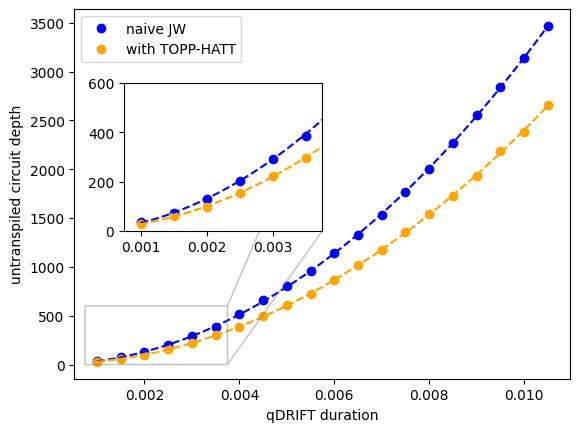

In [19]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

fig, ax = plt.subplots()

ax.plot(depths, JW_mean_depths, 'o', label='naive JW', color=naive_edge)
ax.plot(depths, TH_mean_depths, 'o', label='with TOPP-HATT', color=tophatt_edge)

depths_fine = np.linspace(min(depths), max(depths), 100)

ax.plot(depths_fine, JW_fit(depths_fine), '--', color=naive_edge)
ax.plot(depths_fine, TH_fit(depths_fine), '--', color=tophatt_edge)

ax.legend()

ax.set_xlabel('qDRIFT duration')
ax.set_ylabel('untranspiled circuit depth')

axin = ax.inset_axes([0.1, 0.4, 0.4, 0.4])

axin.plot(depths, JW_mean_depths, 'o', label='naive JW', color=naive_edge)
axin.plot(depths, TH_mean_depths, 'o', label='with TOPP-HATT', color=tophatt_edge)

axin.plot(depths_fine, JW_fit(depths_fine), '--', color=naive_edge)
axin.plot(depths_fine, TH_fit(depths_fine), '--', color=tophatt_edge)

axin.set_xlim(0.00075, 0.00375)
axin.set_ylim(0, 600)

ax.indicate_inset_zoom(axin)

plt.show()